# Dynamic Hand Gesture Recognition 
### Architecture
1. **MediaPipe Hands** (Tasks API, VIDEO mode) 21-keypoint hand tracking + bounding-box crop
2. **EfficientNetB3** (timm, pretrained ImageNet) spatial feature extractor per frame crop
3. **Transformer Encoder** temporal classifier over the fixed-length feature sequence

### Annotation format (`Annot_TrainList.txt`)

- Only 5 gesture IDs are kept for rapid iteration: 2, 6, 7, 9, 10
- `ID_TO_CLASS` dict maps each kept annotation id to model class index 0 to 4
- `t_start` / `t_end` are **1-based absolute frame numbers** inside the video file

### Key design decisions
| Decision | Rationale |
|---|---|
| Seek to `t_start` before reading | Clips start anywhere in a 10-min video, reading from frame 0 wastes time and often misses the clip entirely |
| Fresh MediaPipe tracker per clip | VIDEO mode is stateful; reusing across clips corrupts tracking state |
| Cache features to disk | EfficientNetB3 inference is computationally heavy; caching makes epoch 2+ nearly instant |
| Oversampling (minority → majority count) | B0A (Pointing) is 5x more frequent. Minority classes are oversampled to match B0A's count (~616) so each class contributes equally. Standard CrossEntropyLoss prevents double-penalising the majority. |

## 1 Install Dependencies

In [42]:
# Run once per environment
!pip install mediapipe opencv-python timm torchvision kagglehub --quiet



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2 Download IPN Hand Dataset

In [43]:
import kagglehub
_DATASET_ROOT_STR = kagglehub.dataset_download("soumicksarker/ipn-hand-dataset")
print(f"Dataset root: {_DATASET_ROOT_STR}")


Dataset root: C:\Users\Veron Dalumpines\.cache\kagglehub\datasets\soumicksarker\ipn-hand-dataset\versions\7


## 3 Imports & Configuration

In [44]:
import cv2
import mediapipe as mp
import numpy as np
import torch
import torch.nn as nn
import timm
import os
import urllib.request
from collections import deque, Counter
from pathlib import Path
from torchvision import transforms

print(f"PyTorch  : {torch.__version__}")
print(f"MediaPipe: {mp.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")

KEEP_IDS = {2, 6, 7, 9, 10}
ID_TO_CLASS = {2: 0, 6: 1, 7: 2, 9: 3, 10: 4}
GESTURE_LABELS = {
    0: "B0A Pointing (one finger)",
    1: "G03 Throw up",
    2: "G04 Throw down",
    3: "G06 Throw right",
    4: "G07 Open twice",
}
NUM_CLASSES = 5
assert len(GESTURE_LABELS) == NUM_CLASSES
assert list(GESTURE_LABELS.keys()) == list(range(NUM_CLASSES))

class Cfg:
    CAM_ID        = 0
    CAM_W, CAM_H  = 640, 480

    TRIGGER_FRAMES = 15

    # Feature extraction
    SEQ_LEN       = 32
    IMG_SIZE      = (300, 300)  # EfficientNetB3 optimal input
    FEATURE_DIM   = 1536        # EfficientNetB3 global-avg-pool output dim

    # Transformer
    HIDDEN_DIM    = 256
    NUM_HEADS     = 4
    NUM_LAYERS    = 2
    DROPOUT       = 0.4
    DROP_PATH     = 0.1

    # Training
    EPOCHS        = 60   
    BATCH_SIZE    = 16
    LR            = 3e-4
    WEIGHT_DECAY  = 5e-4   
    PATIENCE      = 10          
    VAL_FRACTION  = 0.2
    FINE_TUNE_BACKBONE = True

    # Backbone fine-tune LR 
    BACKBONE_LR   = 3e-5   # 10x lower than classifier LR 

    CONF_THRESHOLD = 0.20

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Config loaded. Device:", Cfg.DEVICE)


PyTorch  : 2.6.0+cu124
MediaPipe: 0.10.35
CUDA     : True
Config loaded. Device: cuda


## 4 MediaPipe Hand Landmarker (Tasks API)

In [45]:
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

MODEL_PATH = "hand_landmarker.task"
if not Path(MODEL_PATH).exists():
    print("Downloading hand_landmarker.task (~8 MB) ...")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/"
        "hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task",
        MODEL_PATH,
    )
    print("Done.")
else:
    print(f"Model already present: {MODEL_PATH}")


def build_hands_tracker() -> mp_vision.HandLandmarker:
    """
    Return a fresh HandLandmarker in VIDEO mode.
    VIDEO mode is stateful always create a new instance per video clip
    so internal tracking state never leaks between clips.
    """
    opts = mp_vision.HandLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=MODEL_PATH),
        num_hands=1,
        min_hand_detection_confidence=0.60,
        min_hand_presence_confidence=0.50,
        min_tracking_confidence=0.50,
        running_mode=mp_vision.RunningMode.VIDEO,
    )
    return mp_vision.HandLandmarker.create_from_options(opts)


# Hand skeleton connections for drawing
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (5,9),(9,10),(10,11),(11,12),
    (9,13),(13,14),(14,15),(15,16),
    (13,17),(17,18),(18,19),(19,20),
    (0,17),
]

def draw_hand(frame_bgr: np.ndarray, hand_landmarks_list) -> None:
    h, w = frame_bgr.shape[:2]
    for hand_lms in hand_landmarks_list:
        pts = [(int(lm.x * w), int(lm.y * h)) for lm in hand_lms]
        for a, b in HAND_CONNECTIONS:
            cv2.line(frame_bgr, pts[a], pts[b], (255, 80, 0), 2)
        for pt in pts:
            cv2.circle(frame_bgr, pt, 3, (0, 255, 120), -1)


def get_hand_bbox(frame: np.ndarray, hand_landmarks, pad: int = 30):
    """
    Return (crop, (x_min, y_min, x_max, y_max)) for the detected hand.
    crop is a square region centred on the hand bounding box.
    Falls back to the full frame if landmarks are empty.
    """
    h, w = frame.shape[:2]
    xs = [lm.x * w for lm in hand_landmarks]
    ys = [lm.y * h for lm in hand_landmarks]
    cx = (min(xs) + max(xs)) / 2
    cy = (min(ys) + max(ys)) / 2
    half = max(max(xs) - min(xs), max(ys) - min(ys)) / 2 + pad
    x0, x1 = int(max(0, cx - half)), int(min(w, cx + half))
    y0, y1 = int(max(0, cy - half)), int(min(h, cy + half))
    return frame[y0:y1, x0:x1], (x0, y0, x1, y1)


print("MediaPipe helpers ready.")


Model already present: hand_landmarker.task
MediaPipe helpers ready.


## 5 Open-Palm Activation Trigger

Hold an open palm for `Cfg.TRIGGER_FRAMES` consecutive frames to arm the system.
Recording starts the moment the palm closes or moves into a gesture pose.

In [46]:
FINGER_TIPS = [8, 12, 16, 20]  # index/middle/ring/pinky tip landmark ids
FINGER_PIPS = [6, 10, 14, 18]  # corresponding PIP joint ids


def is_open_palm(hand_landmarks, handedness: str = "Right") -> bool:
    """
    True when >=3 fingers are extended and the thumb is abducted.
    handedness: Tasks-API anatomical label ('Right' or 'Left').
    """
    lm = hand_landmarks
    fingers_up = sum(lm[tip].y < lm[pip].y for tip, pip in zip(FINGER_TIPS, FINGER_PIPS))
    thumb_abducted = (lm[4].x > lm[2].x) if handedness == "Right" else (lm[4].x < lm[2].x)
    return fingers_up >= 3 and thumb_abducted


print("Activation trigger ready.")


Activation trigger ready.


## 6 Spatial Feature Extractor

In [47]:
class SpatialExtractor(nn.Module):
    """
    EfficientNetB3 with the classification head removed.
    Returns a (FEATURE_DIM,) = (1536,) global-avg-pool embedding per frame.

    Partial fine-tuning: last convolutional blocks are trainable;
    everything else is frozen.
    """
    def __init__(self, device: str = "cpu"):
        super().__init__()
        self.backbone = timm.create_model(
            "efficientnet_b3", pretrained=True, num_classes=0
        )

        for p in self.backbone.parameters():
            p.requires_grad = False

        if Cfg.FINE_TUNE_BACKBONE:
            # Unfreeze the final blocks for EfficientNetB3
            for name, p in self.backbone.named_parameters():
                if "conv_head" in name or "bn2" in name or "blocks.6" in name:
                    p.requires_grad = True

        n_trainable = sum(p.numel() for p in self.backbone.parameters() if p.requires_grad)
        n_total     = sum(p.numel() for p in self.backbone.parameters())
        print(f"EfficientNetB3: {n_trainable:,} / {n_total:,} params trainable")

        self.preprocess = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(Cfg.IMG_SIZE),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])
        self.to(device)

    @torch.no_grad()
    def encode(self, crop_bgr: np.ndarray) -> torch.Tensor | None:
        if crop_bgr is None or crop_bgr.size == 0:
            return None
        was_training = self.backbone.training
        self.backbone.eval()
        rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        t   = self.preprocess(rgb).unsqueeze(0).to(next(self.backbone.parameters()).device)
        out = self.backbone(t).squeeze(0).cpu()
        if was_training:
            self.backbone.train()
        return out

    def encode_train(self, crop_bgr: np.ndarray) -> torch.Tensor | None:
        if crop_bgr is None or crop_bgr.size == 0:
            return None
        rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        t   = self.preprocess(rgb).unsqueeze(0).to(next(self.backbone.parameters()).device)
        return self.backbone(t).squeeze(0).cpu()

print("Loading EfficientNetB3 weights (~45 MB, downloads once) ...")
spatial_extractor = SpatialExtractor(device=Cfg.DEVICE)
print(f"SpatialExtractor ready on {Cfg.DEVICE}.")

Loading EfficientNetB3 weights (~45 MB, downloads once) ...
EfficientNetB3: 3,908,218 / 10,696,232 params trainable
SpatialExtractor ready on cuda.


## 7 Temporal Classifier Transformer Encoder

In [48]:
import math


class StochasticDepthTransformerLayer(nn.Module):
    def __init__(self, layer: nn.TransformerEncoderLayer, drop_path_prob: float = 0.0):
        super().__init__()
        self.layer         = layer
        self.drop_path_prob = drop_path_prob

    def forward(self, x, src_key_padding_mask=None):
        if self.training and self.drop_path_prob > 0.0:
            if torch.rand(1).item() < self.drop_path_prob:
                return x   
        return self.layer(x, src_key_padding_mask=src_key_padding_mask)


class TemporalTransformer(nn.Module):
    def __init__(
        self,
        feature_dim  : int   = Cfg.FEATURE_DIM,
        num_classes  : int   = NUM_CLASSES,
        hidden_dim   : int   = Cfg.HIDDEN_DIM,
        num_heads    : int   = Cfg.NUM_HEADS,
        num_layers   : int   = Cfg.NUM_LAYERS,
        dropout      : float = Cfg.DROPOUT,
        drop_path    : float = Cfg.DROP_PATH,
        max_seq_len  : int   = 256,
    ):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, hidden_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        pe  = torch.zeros(max_seq_len + 1, hidden_dim)
        pos = torch.arange(max_seq_len + 1).float().unsqueeze(1)
        div = torch.exp(
            torch.arange(0, hidden_dim, 2).float() * -(math.log(10000.0) / hidden_dim)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

        dpr = [drop_path * i / max(num_layers - 1, 1) for i in range(num_layers)]

        base_layer = lambda: nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.layers = nn.ModuleList([
            StochasticDepthTransformerLayer(base_layer(), dpr[i])
            for i in range(num_layers)
        ])
        self.norm = nn.LayerNorm(hidden_dim)

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

        self.feat_drop = nn.Dropout(p=0.15)

        n_params = sum(p.numel() for p in self.parameters())
        print(f"TemporalTransformer: {n_params:,} parameters  ")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, _ = x.shape
        x   = self.feat_drop(x)
        x   = self.input_proj(x)                    
        cls = self.cls_token.expand(B, -1, -1)      
        x   = torch.cat([cls, x], dim=1)            
        x   = x + self.pe[:, :T + 1]
        for layer in self.layers:
            x = layer(x)
        x   = self.norm(x)
        return self.head(x[:, 0])                   


temporal_classifier = TemporalTransformer().to(Cfg.DEVICE)


TemporalTransformer: 1,975,557 parameters  


## 8 Load Pre-trained Weights (Optional)

Point `MODEL_WEIGHTS` at a saved `.pt` checkpoint produced by Cell 10.
Leave it as `None` to start from scratch.

In [49]:
# Set to None to start training from scratch.
MODEL_WEIGHTS = 'checkpoints/best_model.pt'

if MODEL_WEIGHTS and os.path.isfile(MODEL_WEIGHTS):
    ckpt = torch.load(MODEL_WEIGHTS, map_location=Cfg.DEVICE)
    temporal_classifier.load_state_dict(ckpt["temporal_classifier"])

    if "conf_threshold" in ckpt:
        Cfg.CONF_THRESHOLD = ckpt["conf_threshold"]
    if "fine_tuned_backbone" in ckpt:
        Cfg.FINE_TUNE_BACKBONE = ckpt["fine_tuned_backbone"]

    saved_cfg = ckpt.get("cfg", {})
    print(f"Loaded weights from {MODEL_WEIGHTS}")
elif MODEL_WEIGHTS:
    print(f"Checkpoint not found at \'{MODEL_WEIGHTS}\'")
else:
    print("MODEL_WEIGHTS = None  using random weights (fresh training run).")

temporal_classifier.eval()

Loaded weights from checkpoints/best_model.pt


TemporalTransformer(
  (input_proj): Sequential(
    (0): Linear(in_features=1536, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (layers): ModuleList(
    (0-1): 2 x StochasticDepthTransformerLayer(
      (layer): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.4, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.4, inplace=False)
        (dropout2): Dropout(p=0.4, inplace=False)
      )
    )
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Dropout(

## 9 Webcam Inference Pipeline

**State machine:**
```
IDLE (open palm x TRIGGER_FRAMES) ARMED (hand leaves palm pose) RECORDING (SEQ_LEN frames) IDLE
```


In [50]:
class GestureState:
    IDLE      = "IDLE"
    ARMED     = "ARMED"
    RECORDING = "RECORDING"

class GesturePipeline:
    MAX_MISSED_FRAMES = 8  

    def __init__(self, spatial_ext: SpatialExtractor, temporal_cls: TemporalTransformer):
        self.spatial  = spatial_ext
        self.temporal = temporal_cls
        self.labels   = GESTURE_LABELS
        self.hands = build_hands_tracker()
        self._reset_state()
        self.last_prediction  = ""
        self.last_confidence  = 0.0
        self.recent_logits    = deque(maxlen=3) 

    def _reset_state(self):
        self.state           = GestureState.IDLE
        self.trigger_count   = 0
        self.missed_frames   = 0
        self.last_feat       = None
        self._discard_frames = 0
        self.feat_buffer     = deque(maxlen=Cfg.SEQ_LEN)
        self.recent_logits.clear() if hasattr(self, "recent_logits") else None

    def _classify(self) -> tuple[str, float]:
        feats = torch.stack(list(self.feat_buffer)).unsqueeze(0).to(Cfg.DEVICE)
        with torch.no_grad():
            T = getattr(self, "temperature", 1.0)
            self.temporal.eval()
            all_probs = [torch.softmax(self.temporal(feats) / T, dim=-1)]
            self.temporal.train()
            for _ in range(3):
                all_probs.append(torch.softmax(self.temporal(feats) / T, dim=-1))
            self.temporal.eval()
        avg_probs = torch.stack(all_probs).mean(0)   
        self.recent_logits.append(avg_probs.cpu())
        avg   = torch.stack(list(self.recent_logits)).mean(0)
        probs = avg.squeeze(0)
        conf, idx = probs.max(dim=-1)
        if conf.item() < Cfg.CONF_THRESHOLD:  
            return " (low confidence)", conf.item()
        return self.labels.get(idx.item(), f"Class {idx.item()}"), conf.item()

    def process(self, frame_bgr: np.ndarray, timestamp_ms: int) -> np.ndarray:
        rgb      = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        mp_img   = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        results  = self.hands.detect_for_video(mp_img, timestamp_ms)

        bbox          = None
        hand_detected = bool(results.hand_landmarks)

        if hand_detected:
            self.missed_frames = 0
            hand_lm    = results.hand_landmarks[0]
            handedness = results.handedness[0][0].category_name
            draw_hand(frame_bgr, results.hand_landmarks)
            crop, bbox = get_hand_bbox(frame_bgr, hand_lm)
            triggered  = is_open_palm(hand_lm, handedness)

            if self.state == GestureState.IDLE:
                if triggered:
                    self.trigger_count += 1
                    if self.trigger_count >= Cfg.TRIGGER_FRAMES:
                        self.state = GestureState.ARMED
                        self.trigger_count = 0
                else:
                    self.trigger_count = 0

            elif self.state == GestureState.ARMED:
                if not triggered:
                    self.state           = GestureState.RECORDING
                    self.feat_buffer.clear()
                    self._discard_frames = 3   
                    self.last_feat       = None

            elif self.state == GestureState.RECORDING:
                if self._discard_frames > 0:
                    self._discard_frames -= 1
                else:
                    feat = self.spatial.encode(crop)
                    if feat is not None:
                        self.feat_buffer.append(feat)
                        self.last_feat = feat
                if len(self.feat_buffer) >= Cfg.SEQ_LEN:
                    self.last_prediction, self.last_confidence = self._classify()
                    self._reset_state()

        else:
            self.missed_frames += 1

            if self.state == GestureState.RECORDING:
                pad = self.last_feat if self.last_feat is not None else torch.zeros(Cfg.FEATURE_DIM)
                self.feat_buffer.append(pad)
                if len(self.feat_buffer) >= Cfg.SEQ_LEN:
                    self.last_prediction, self.last_confidence = self._classify()
                    self._reset_state()
                elif self.missed_frames >= self.MAX_MISSED_FRAMES:
                    if len(self.feat_buffer) >= Cfg.SEQ_LEN // 2:
                        self.last_prediction, self.last_confidence = self._classify()
                    self._reset_state()

            elif self.state == GestureState.ARMED:
                if self.missed_frames >= self.MAX_MISSED_FRAMES:
                    self._reset_state()

            else:
                self.trigger_count = 0

        self._draw_overlay(frame_bgr, bbox)
        return frame_bgr

    def _draw_overlay(self, frame: np.ndarray, bbox) -> None:
        h, w = frame.shape[:2]
        STATE_COLOR = {
            GestureState.IDLE:      (180, 180, 180),
            GestureState.ARMED:     (0,   200, 255),
            GestureState.RECORDING: (0,   60,  255),
        }
        color = STATE_COLOR[self.state]

        if bbox:
            cv2.rectangle(frame, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 2)

        cv2.rectangle(frame, (0, 0), (w, 100), (15, 15, 15), -1)

        if self.state == GestureState.IDLE and self.trigger_count > 0:
            pct   = int(self.trigger_count / Cfg.TRIGGER_FRAMES * (w - 20))
            label = f"Hold open palm  ({self.trigger_count}/{Cfg.TRIGGER_FRAMES})"
            cv2.rectangle(frame, (10, 78), (10 + pct, 92), (0, 200, 255), -1)
            cv2.rectangle(frame, (10, 78), (w - 10, 92), (80, 80, 80), 1)
        elif self.state == GestureState.ARMED:
            label = "ARMED perform gesture now"
        elif self.state == GestureState.RECORDING:
            pct   = int(len(self.feat_buffer) / Cfg.SEQ_LEN * (w - 20))
            label = f"RECORDING  ({len(self.feat_buffer)}/{Cfg.SEQ_LEN} frames)"
            cv2.rectangle(frame, (10, 78), (10 + pct, 92), (0, 60, 255), -1)
            cv2.rectangle(frame, (10, 78), (w - 10, 92), (80, 80, 80), 1)
            cv2.circle(frame, (w - 25, 25), 10, (0, 0, 255), -1)
            cv2.putText(frame, "REC", (w - 68, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 255), 2)
        else:
            label = "IDLE show open palm to activate"

        cv2.putText(frame, label, (10, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2)
        cv2.putText(
            frame,
            f"Gesture: {self.last_prediction}  ({self.last_confidence:.0%})",
            (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (50, 255, 50), 2,
        )

    def close(self):
        self.hands.close()

print("GesturePipeline ready.")


GesturePipeline ready.


## 10 Run Webcam Inference

In [51]:
temporal_classifier.eval()
spatial_extractor.backbone.eval()

pipeline = GesturePipeline(spatial_extractor, temporal_classifier)
cap      = cv2.VideoCapture(Cfg.CAM_ID)
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  Cfg.CAM_W)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, Cfg.CAM_H)

import time
t0 = time.time()
print("Press Q to quit.")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Camera read failed.")
            break
        ts_ms  = int((time.time() - t0) * 1000)
        output = pipeline.process(frame, ts_ms)
        cv2.imshow("IPN Gesture Recognition", output)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
finally:
    cap.release()
    cv2.destroyAllWindows()
    pipeline.close()
    print("Pipeline closed.")


Press Q to quit.
Pipeline closed.


## 11 Train the Temporal Classifier on IPN Hand Features

In [52]:
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import pandas as pd

torch.backends.cudnn.benchmark = True

_DATASET_ROOT = Path(_DATASET_ROOT_STR)  

def _find_annotation_file(root: Path) -> Path:
    for search_root in [root / "annotations" / "annotations", root / "annotations", root]:
        if not search_root.exists():
            continue
        for pattern in ["Annot_TrainList.txt", "Annot_TrainList.csv",
                         "Annot_List.txt", "Annot*.txt", "Annot*.csv"]:
            hits = [p for p in search_root.rglob(pattern)
                    if p.name.lower() != "metadata.csv"]
            if hits:
                return hits[0]
    raise FileNotFoundError(f"No Annot_*List file found under {root}")

def _find_video_dir(root: Path) -> Path:
    for ext in ("*.avi", "*.mp4"):
        vids = list(root.rglob(ext))
        if vids:
            return vids[0].parent
    raise FileNotFoundError(f"No video files found under {root}")

def _load_annotations(annot_path: Path) -> pd.DataFrame:
    with open(annot_path) as f:
        first_line = f.readline().strip()

    has_header = first_line.lower().startswith("video")
    if has_header:
        df = pd.read_csv(annot_path)
        df = df.rename(columns={"video": "video_name"})
    else:
        df = pd.read_csv(
            annot_path, header=None,
            names=["video_name", "label", "id", "t_start", "t_end", "frames"],
        )
    df["id"] = df["id"].astype(int)
    df["t_start"] = df["t_start"].astype(int)
    df["t_end"]   = df["t_end"].astype(int)
    return df[["video_name", "label", "id", "t_start", "t_end"]].dropna()

_ANNOT_FILE = _find_annotation_file(_DATASET_ROOT)
_VIDEO_DIR  = _find_video_dir(_DATASET_ROOT)
print(f"Annotation file : {_ANNOT_FILE}")
print(f"Videos directory: {_VIDEO_DIR}")

FEATURE_CACHE = Path("feature_cache")
FEATURE_CACHE.mkdir(exist_ok=True)

def extract_clip_features(
    video_path: Path,
    t_start: int,
    t_end: int,
    spatial_ext: SpatialExtractor,
    seq_len: int = Cfg.SEQ_LEN,
) -> torch.Tensor:
    hands = build_hands_tracker()   
    ts    = 0                       
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        hands.close()
        return torch.zeros(seq_len, Cfg.FEATURE_DIM)

    cap.set(cv2.CAP_PROP_POS_FRAMES, t_start)
    clip_len    = max(1, t_end - t_start)
    sample_pos  = set(round(i * clip_len / seq_len) for i in range(seq_len))
    feats    = []
    frame_no = 0  

    while cap.isOpened() and len(feats) < seq_len:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_no in sample_pos:
            ts += 33  
            rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            result = hands.detect_for_video(mp_img, ts)
            if result.hand_landmarks:
                crop, _ = get_hand_bbox(frame, result.hand_landmarks[0])
            else:
                crop = frame   
            feat = spatial_ext.encode(crop)
            if feat is not None:
                feats.append(feat)
        frame_no += 1

    cap.release()
    hands.close()   
    while len(feats) < seq_len:
        feats.append(torch.zeros(Cfg.FEATURE_DIM))
    return torch.stack(feats[:seq_len])   

class IPNHandDataset(Dataset):
    def __init__(
        self,
        annot_path : Path,
        video_dir  : Path,
        spatial_ext: SpatialExtractor,
        seq_len    : int = Cfg.SEQ_LEN,
    ):
        self.video_dir   = video_dir
        self.spatial_ext = spatial_ext
        self.seq_len     = seq_len
        df = _load_annotations(annot_path)
        df = df[df["id"].isin(KEEP_IDS)].reset_index(drop=True)
        self.records = df
        print(f"IPNHandDataset: {len(self.records)} gesture clips ")

    def _cache_path(self, row) -> Path:
        return FEATURE_CACHE / f"{row['video_name']}_{row['t_start']}_{row['t_end']}.pt"

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        row   = self.records.iloc[idx]
        cache = self._cache_path(row)
        label = ID_TO_CLASS[int(row["id"])]  

        if cache.exists():
            feats = torch.load(cache, weights_only=True)
        else:
            stem = str(row["video_name"])
            path = self.video_dir / (stem + ".avi")
            if not path.exists():
                path = self.video_dir / (stem + ".mp4")
            feats = extract_clip_features(
                path, row["t_start"], row["t_end"],
                self.spatial_ext, self.seq_len,
            )
            torch.save(feats, cache)
        return feats, label

def mixup_batch(feats: torch.Tensor, labels: torch.Tensor, alpha: float = 0.3):
    if alpha <= 0 or not feats.requires_grad and torch.rand(1).item() > 0.5:
        one_hot = torch.zeros(len(labels), NUM_CLASSES, device=labels.device)
        one_hot.scatter_(1, labels.unsqueeze(1), 1.0)
        return feats, one_hot

    lam    = float(torch.distributions.Beta(alpha, alpha).sample())
    B      = feats.size(0)
    idx    = torch.randperm(B, device=feats.device)
    mixed  = lam * feats + (1 - lam) * feats[idx]
    one_hot = torch.zeros(B, NUM_CLASSES, device=labels.device)
    one_hot.scatter_(1, labels.unsqueeze(1), 1.0)
    mixed_labels = lam * one_hot + (1 - lam) * one_hot[idx]
    return mixed, mixed_labels

def soft_cross_entropy(logits: torch.Tensor, soft_labels: torch.Tensor) -> torch.Tensor:
    log_probs = torch.log_softmax(logits, dim=-1)
    return -(soft_labels * log_probs).sum(dim=-1).mean()

def train(
    spatial_ext  : SpatialExtractor,
    classifier   : TemporalTransformer,
    annot_path   : Path = _ANNOT_FILE,
    video_dir    : Path = _VIDEO_DIR,
    epochs       : int   = Cfg.EPOCHS,
    batch_size   : int   = Cfg.BATCH_SIZE,
    lr           : float = Cfg.LR,
    val_fraction : float = Cfg.VAL_FRACTION,
    patience     : int   = Cfg.PATIENCE,
    save_path    : str   = "checkpoints/best_model.pt",
):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    classifier.__init__(
        feature_dim=Cfg.FEATURE_DIM,
        num_classes=NUM_CLASSES,
        hidden_dim=Cfg.HIDDEN_DIM,
        num_heads=Cfg.NUM_HEADS,
        num_layers=Cfg.NUM_LAYERS,
        dropout=Cfg.DROPOUT,
    )
    classifier.to(Cfg.DEVICE)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    full_ds = IPNHandDataset(annot_path, video_dir, spatial_ext)
    val_n   = int(val_fraction * len(full_ds))
    train_n = len(full_ds) - val_n
    train_ds, val_ds = random_split(
        full_ds, [train_n, val_n],
        generator=torch.Generator().manual_seed(42),
    )
    print(f"\nSplit: {train_n} train / {val_n} val")

    # Class normalisation via oversampling
    class_to_indices: dict[int, list[int]] = {}
    for ds_idx in train_ds.indices:
        c = ID_TO_CLASS[int(full_ds.records.iloc[ds_idx]["id"])]
        class_to_indices.setdefault(c, []).append(ds_idx)

    counts = {c: len(idxs) for c, idxs in class_to_indices.items()}
    print("Train class counts (before balancing):",
          {GESTURE_LABELS[k]: v for k, v in sorted(counts.items())})

    # Oversample every minority class up to the majority class size.
    max_count = max(counts.values())
    rng = np.random.default_rng(42)
    balanced_indices: list[int] = []
    for c in sorted(class_to_indices):
        idxs = class_to_indices[c]
        # Tile the index list then trim to exactly max_count.
        repeated = (idxs * ((max_count // len(idxs)) + 1))[:max_count]
        balanced_indices.extend(repeated)
    rng.shuffle(balanced_indices)

    balanced_counts = Counter(
        ID_TO_CLASS[int(full_ds.records.iloc[i]["id"])] for i in balanced_indices
    )
    print("Train class counts (after  balancing):",
          {GESTURE_LABELS[k]: v for k, v in sorted(balanced_counts.items())})
    print(f"Total balanced train samples: {len(balanced_indices)}")

    balanced_ds = Subset(full_ds, balanced_indices)

    train_loader = DataLoader(
        balanced_ds, batch_size=batch_size, shuffle=True,
        num_workers=0, pin_memory=(Cfg.DEVICE == "cuda"),
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=0, pin_memory=(Cfg.DEVICE == "cuda"),
    )

    # Loss: Standard CE
    # Classes are already balanced by oversampling, so plain CrossEntropyLoss
    # (no weights) is used to avoid double-penalising the majority class.
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    backbone_params = [p for p in spatial_ext.backbone.parameters() if p.requires_grad]
    param_groups = [{"params": classifier.parameters(), "lr": lr}]
    if backbone_params:
        param_groups.append({"params": backbone_params, "lr": Cfg.BACKBONE_LR})
        print(f"Fine-tuning backbone: {sum(p.numel() for p in backbone_params):,} params at lr={Cfg.BACKBONE_LR}")
    else:
        print("Backbone fully frozen only training classifier.")
    optimizer = optim.AdamW(param_groups, weight_decay=Cfg.WEIGHT_DECAY)

    def lr_lambda(ep):
        warmup = 3
        if ep < warmup:
            return (ep + 1) / warmup
        period   = epochs * 1.5
        progress = (ep - warmup) / max(1, period - warmup)
        progress = min(progress, 1.0)
        return 0.5 * (1 + __import__('math').cos(__import__('math').pi * progress))
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    best_val_acc     = 0.0   
    patience_counter = 0


    for epoch in range(1, epochs + 1):
        classifier.train()
        spatial_ext.backbone.train()
        tr_loss = tr_correct = tr_total = 0

        for feats, labels in train_loader:
            feats  = feats.to(Cfg.DEVICE, non_blocking=True)
            labels = labels.to(Cfg.DEVICE, non_blocking=True)
            mixed_feats, soft_labels = mixup_batch(feats, labels, alpha=0.3)
            optimizer.zero_grad()
            logits = classifier(mixed_feats)
            loss   = soft_cross_entropy(logits, soft_labels) 
            loss.backward()
            nn.utils.clip_grad_norm_(classifier.parameters(), max_norm=1.0)
            optimizer.step()
            with torch.no_grad():
                clean_logits = classifier(feats)
            tr_loss    += loss.item() * len(labels)
            tr_correct += (clean_logits.argmax(1) == labels).sum().item()
            tr_total   += len(labels)

        classifier.eval()
        spatial_ext.backbone.eval()
        val_loss = val_correct = val_total = 0

        with torch.no_grad():
            for feats, labels in val_loader:
                feats  = feats.to(Cfg.DEVICE, non_blocking=True)
                labels = labels.to(Cfg.DEVICE, non_blocking=True)
                all_probs = [torch.softmax(classifier(feats), dim=-1)]
                classifier.train()
                for _ in range(3):
                    all_probs.append(torch.softmax(classifier(feats), dim=-1))
                classifier.eval()
                avg_probs = torch.stack(all_probs).mean(0)  
                loss = criterion(torch.log(all_probs[0].clamp(min=1e-8)), labels)
                val_loss    += loss.item() * len(labels)
                val_correct += (avg_probs.argmax(1) == labels).sum().item()
                val_total   += len(labels)
        scheduler.step()

        avg_tr  = tr_loss  / tr_total
        avg_val = val_loss / val_total
        tr_acc  = tr_correct / tr_total
        val_acc_epoch = val_correct / val_total

        history["train_loss"].append(avg_tr)
        history["train_acc"].append(tr_acc * 100)
        history["val_loss"].append(avg_val)
        history["val_acc"].append(val_acc_epoch * 100)

        print(
            f"Epoch {epoch:3d}/{epochs}"
            f"  train_loss={avg_tr:.4f}  train_acc={tr_acc:.2%}"
            f"  val_loss={avg_val:.4f}  val_acc={val_acc_epoch:.2%}"
        )

        cur_val_acc = val_correct / val_total
        if cur_val_acc > best_val_acc:
            best_val_acc     = cur_val_acc
            patience_counter = 0
            torch.save({
                "temporal_classifier": classifier.state_dict(),
                "fine_tuned_backbone": Cfg.FINE_TUNE_BACKBONE,
                "conf_threshold":      Cfg.CONF_THRESHOLD,
                "cfg": {
                    "HIDDEN_DIM":          Cfg.HIDDEN_DIM,
                    "NUM_HEADS":           Cfg.NUM_HEADS,
                    "NUM_LAYERS":          Cfg.NUM_LAYERS,
                    "FEATURE_DIM":         Cfg.FEATURE_DIM,
                    "NUM_CLASSES":         NUM_CLASSES,
                    "SEQ_LEN":             Cfg.SEQ_LEN,
                    "FINE_TUNE_BACKBONE":  Cfg.FINE_TUNE_BACKBONE,
                },
            }, save_path)
            print(f"  ✓ Checkpoint saved → {save_path}  (val_acc={best_val_acc:.2%})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stop at epoch {epoch}. Best: {best_val_acc:.2%}")
                break
    classifier.eval()
    spatial_ext.backbone.eval()

    print("\nTraining complete.")

    return history


Annotation file : C:\Users\Veron Dalumpines\.cache\kagglehub\datasets\soumicksarker\ipn-hand-dataset\versions\7\annotations\annotations\Annot_TrainList.txt
Videos directory: C:\Users\Veron Dalumpines\.cache\kagglehub\datasets\soumicksarker\ipn-hand-dataset\versions\7\videos\videos


## 12 Start Training

In [53]:
training_history = train(
    spatial_extractor,
    temporal_classifier,
    annot_path = _ANNOT_FILE,
    video_dir  = _VIDEO_DIR,
    epochs     = Cfg.EPOCHS,
    batch_size = Cfg.BATCH_SIZE,
    lr         = Cfg.LR,
    save_path  = "checkpoints/best_model.pt",
)

TemporalTransformer: 1,975,557 parameters  
IPNHandDataset: 1338 gesture clips 

Split: 1071 train / 267 val
Train class counts (before balancing): {'B0A Pointing (one finger)': 616, 'G03 Throw up': 114, 'G04 Throw down': 115, 'G06 Throw right': 116, 'G07 Open twice': 110}
Train class counts (after  balancing): {'B0A Pointing (one finger)': 616, 'G03 Throw up': 616, 'G04 Throw down': 616, 'G06 Throw right': 616, 'G07 Open twice': 616}
Total balanced train samples: 3080
Fine-tuning backbone: 3,908,218 params at lr=3e-05
Epoch   1/60  train_loss=1.1215  train_acc=58.60%  val_loss=0.7872  val_acc=83.15%
  ✓ Checkpoint saved → checkpoints\best_model.pt  (val_acc=83.15%)
Epoch   2/60  train_loss=0.4899  train_acc=92.50%  val_loss=0.8651  val_acc=88.76%
  ✓ Checkpoint saved → checkpoints\best_model.pt  (val_acc=88.76%)
Epoch   3/60  train_loss=0.3546  train_acc=95.84%  val_loss=1.0303  val_acc=88.01%
Epoch   4/60  train_loss=0.3149  train_acc=98.34%  val_loss=0.9128  val_acc=89.51%
  ✓ Check

## 13. Model Evaluation and Metrics Extraction

Saved convergence curves to 'training_convergence.png'


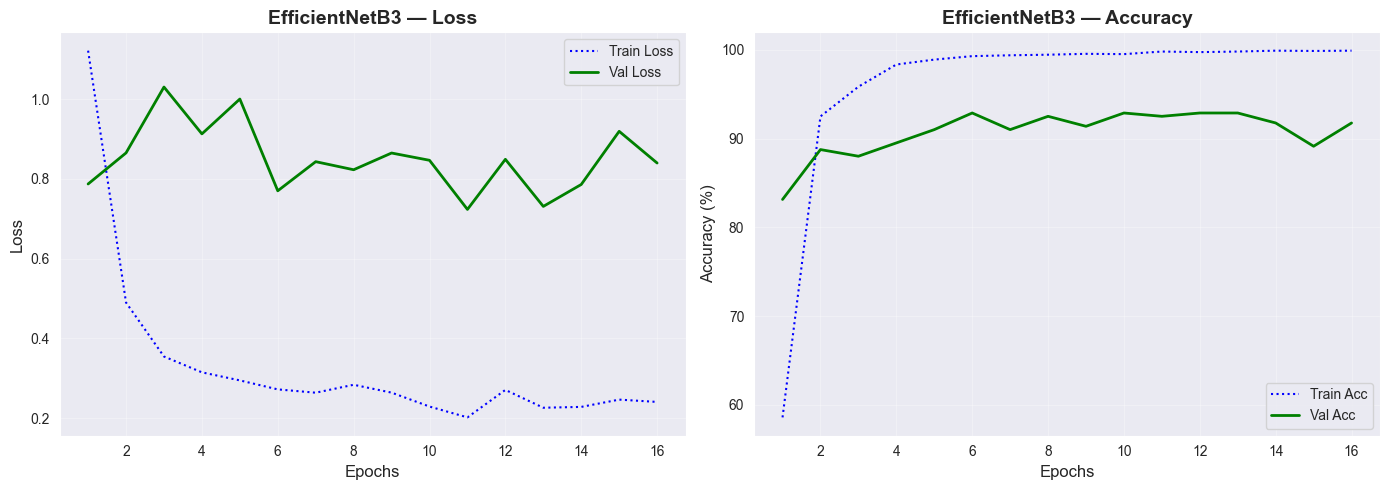


Loading Validation Dataset...
IPNHandDataset: 1338 gesture clips 
Loading Best Model...
Running Inference on Validation Set...

  CLASSIFICATION REPORT — EfficientNetB3 (Validation Set)
                         accuracy precision    recall  f1-score
---------------------------------------------------------------
  Pointing (one finger)    0.9922    0.9846    0.9922    0.9884
               Throw up    0.9706    0.7674    0.9706    0.8571
             Throw down    0.8235    0.8750    0.8235    0.8485
            Throw right    0.8125    0.9286    0.8125    0.8667
             Open twice    0.8421    0.9412    0.8421    0.8889
---------------------------------------------------------------
                Average    0.8882    0.8994    0.8882    0.8899

Saved confusion matrix to 'confusion_matrix.png'


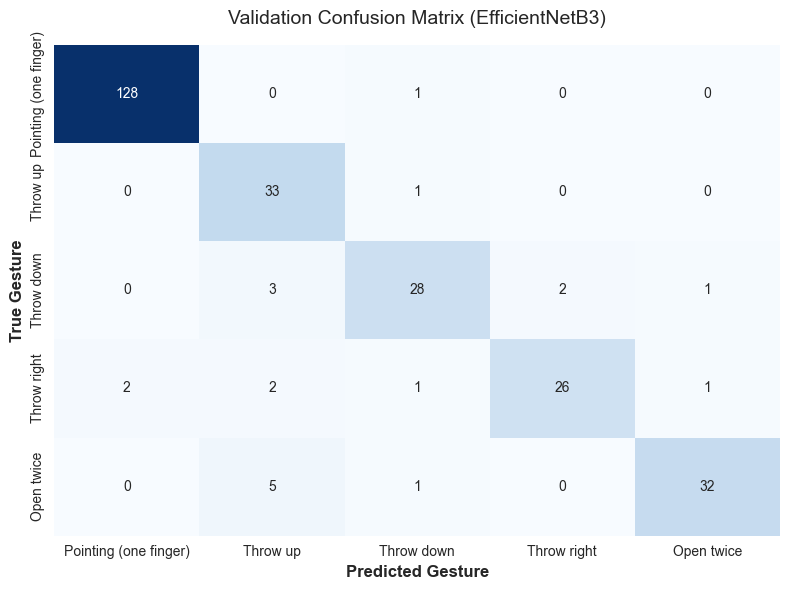

C:\Users\Veron Dalumpines\AppData\Local\Temp\ipykernel_9644\2763583986.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_names, y=f1_scores, palette='viridis')


Saved F1-score bar chart to 'f1_scores_bar.png'


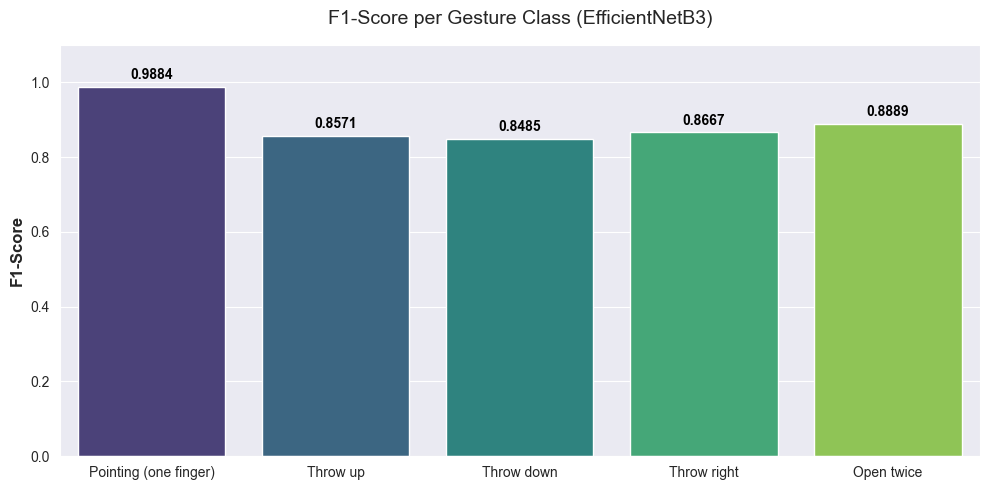

In [54]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import random_split, DataLoader

# ── VISUAL 1: EfficientNetB3 Convergence Curves ───────────────────────────────
epochs_range = range(1, len(training_history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, training_history["train_loss"], label='Train Loss', color='blue', linestyle=':')
ax1.plot(epochs_range, training_history["val_loss"],   label='Val Loss',   color='green', linewidth=2)
ax1.set_title('EfficientNetB3 — Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, training_history["train_acc"], label='Train Acc', color='blue', linestyle=':')
ax2.plot(epochs_range, training_history["val_acc"],   label='Val Acc',   color='green', linewidth=2)
ax2.set_title('EfficientNetB3 — Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_convergence.png', dpi=300, bbox_inches='tight')
print("Saved convergence curves to 'training_convergence.png'")
plt.show()

# ── DATA & INFERENCE PREPARATION ─────────────────────────────────────────────
print("\nLoading Validation Dataset...")
full_ds = IPNHandDataset(_ANNOT_FILE, _VIDEO_DIR, spatial_extractor)
val_n   = int(Cfg.VAL_FRACTION * len(full_ds))
train_n = len(full_ds) - val_n

_, val_ds = random_split(
    full_ds, [train_n, val_n],
    generator=torch.Generator().manual_seed(42)
)
val_loader = DataLoader(
    val_ds, batch_size=Cfg.BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=(Cfg.DEVICE == "cuda")
)

print("Loading Best Model...")
ckpt = torch.load("checkpoints/best_model.pt", map_location=Cfg.DEVICE, weights_only=False)
temporal_classifier.load_state_dict(ckpt["temporal_classifier"])
temporal_classifier.eval()

all_preds, all_labels = [], []
print("Running Inference on Validation Set...")
with torch.no_grad():
    for feats, labels in val_loader:
        feats  = feats.to(Cfg.DEVICE)
        logits = temporal_classifier(feats)
        _, preds = torch.max(logits, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
class_names = [GESTURE_LABELS[i].split(" ", 1)[1] for i in range(NUM_CLASSES)]

# ── CLASSIFICATION REPORT  ─────────────────────────────────────
cm          = confusion_matrix(all_labels, all_preds)
report_dict = classification_report(
    all_labels, all_preds, target_names=class_names, output_dict=True
)

row_sums      = cm.sum(axis=1)
per_class_acc = np.where(row_sums > 0, cm.diagonal() / row_sums, 0.0)

col_headers = ["accuracy", "precision", "recall", "f1-score"]
rows = []
for i, name in enumerate(class_names):
    d = report_dict[name]
    rows.append([per_class_acc[i], d["precision"], d["recall"], d["f1-score"]])

avg_row = np.mean(rows, axis=0).tolist()

col_w   = max(len(n) for n in class_names) + 2
num_w   = 10
header  = f"{'':>{col_w}}" + "".join(f"{h:>{num_w}}" for h in col_headers)
divider = "-" * (col_w + num_w * len(col_headers))

print("\n" + "=" * len(divider))
print(f"  CLASSIFICATION REPORT — EfficientNetB3 (Validation Set)")
print("=" * len(divider))
print(header)
print(divider)
for name, row in zip(class_names, rows):
    print(f"{name:>{col_w}}" + "".join(f"{v:>{num_w}.4f}" for v in row))
print(divider)
print(f"{'Average':>{col_w}}" + "".join(f"{v:>{num_w}.4f}" for v in avg_row))
print("=" * len(divider))

# ── VISUAL 2: Confusion Matrix ────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title('Validation Confusion Matrix (EfficientNetB3)', fontsize=14, pad=15)
plt.ylabel('True Gesture',      fontsize=12, fontweight='bold')
plt.xlabel('Predicted Gesture', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\nSaved confusion matrix to 'confusion_matrix.png'")
plt.show()

# ── VISUAL 3: Per-Class F1-Score Bar Chart ────────────────────────────────────
f1_scores = [report_dict[c]["f1-score"] for c in class_names]

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=class_names, y=f1_scores, palette='viridis')
plt.title('F1-Score per Gesture Class (EfficientNetB3)', fontsize=14, pad=15)
plt.ylabel('F1-Score', fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
for i, v in enumerate(f1_scores):
    ax.text(i, v + 0.02, f"{v:.4f}", color='black', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('f1_scores_bar.png', dpi=300, bbox_inches='tight')
print("Saved F1-score bar chart to 'f1_scores_bar.png'")
plt.show()